In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Ajustes generales para los gráficos
plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [ ]:
def logistic(mu, x):
    return mu * x * (1 - x)

def iterate_logistic(mu, x0, n_steps):
    orbit  = np.empty(n_steps + 1, dtype=float) #lista vacia para guardar x0, x1, x2 ... , xn
    orbit[0] = x0

    x = x0
    for n in range(n_steps):
        x = logistic(mu, x)
        orbit[n + 1] = x

    return orbit


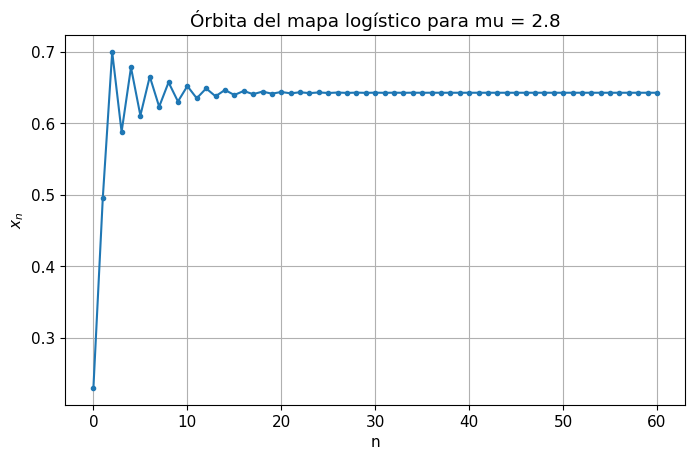

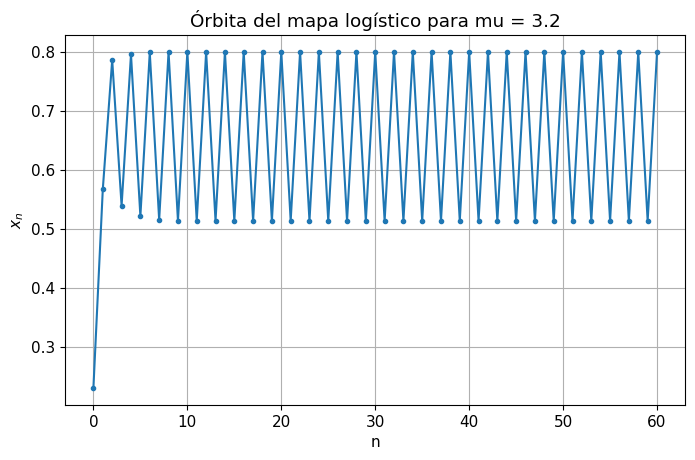

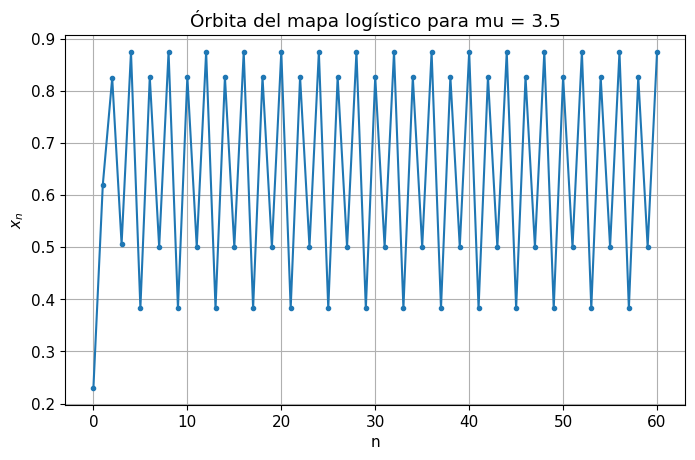

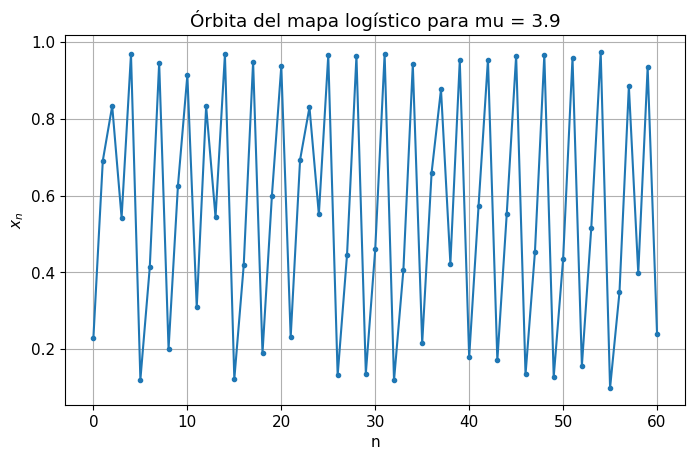

In [ ]:
mu_values = [2.8, 3.2, 3.5, 3.9]
x0 = 0.23
n_steps = 60

for mu in mu_values:
    orbit = iterate_logistic(mu, x0, n_steps)
    plt.figure()
    plt.plot(range(len(orbit)), orbit, marker='o', ms=3)
    plt.title(f'Órbita del mapa logístico para mu = {mu}')
    plt.xlabel("n")
    plt.ylabel("$x_n$")
    plt.show()

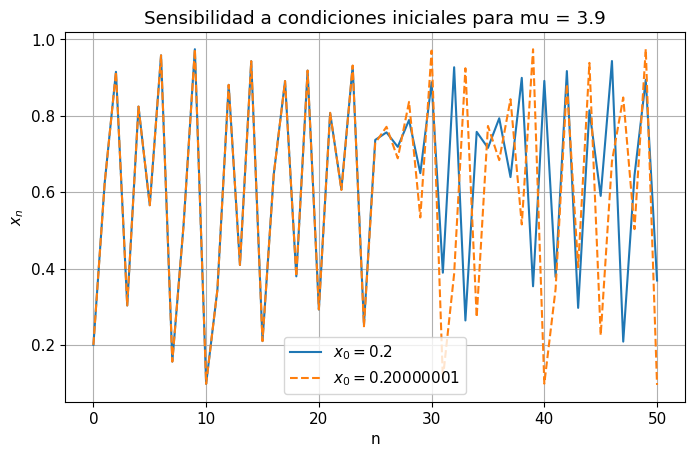

In [ ]:
mu = 3.9
x0 = 0.2
delta = 1E-8
n_steps = 50

orbit1 = iterate_logistic(mu, x0, n_steps)
orbit2 = iterate_logistic(mu, x0 + delta, n_steps)

plt.figure()
plt.plot(orbit1, label=f'$x_0 = {x0}$')
plt.plot(orbit2, "--", label=f'$x_0={x0+delta}$')
plt.title(f'Sensibilidad a condiciones iniciales para mu = {mu}')
plt.xlabel("n")
plt.ylabel("$x_n$")
plt.legend()
plt.show()

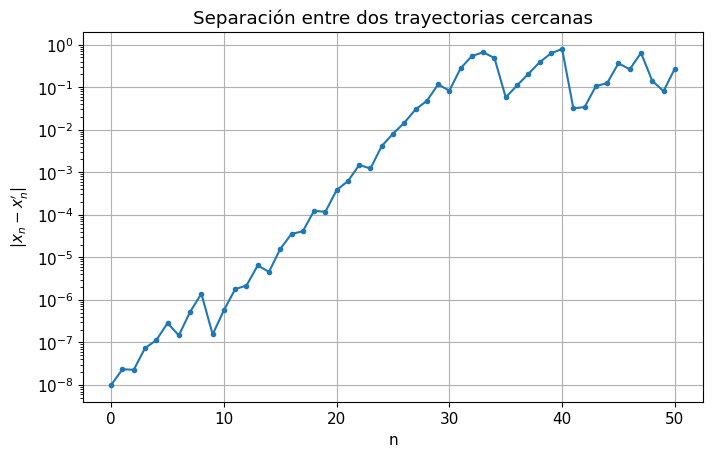

In [ ]:
separation = np.abs(orbit1 - orbit2)

plt.figure()
plt.semilogy(range(len(separation)), separation, marker='o', ms=3)
plt.title(f'Separación entre dos trayectorias cercanas')
plt.xlabel('n')
plt.ylabel(r"$|x_n - x_n'|$")
plt.show()

In [ ]:
def lyapunov_exponent(mu, x0=None, n_transient=1000, n_eval=3000, eps=1E-14):
    #Tomamos el valor inicial x = x0
    if x0 is None:
        x = np.random.random()
    else:
        x = float(x0)

    #Avanzamos la lista por un transiente
    for _ in range(n_transient):
        x = logistic(mu, x)

    #Acumulacion del promedio de log|f'(x_n)|
    s = 0.0
    for _ in range(n_eval):
        derivative = abs(mu * (1.0 - 2.0 * x))
        derivative = max(derivative, eps) #evita el log(0)
        s += np.log(derivative)
        x = logistic(mu, x)

    return s / n_eval

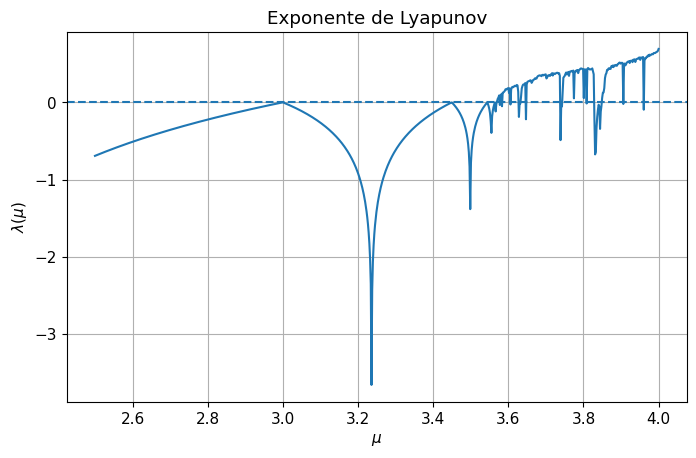

In [ ]:
mu_grid = np.linspace(2.5, 4.0, 800)
lambda_values = np.array([lyapunov_exponent(mu) for mu in mu_grid])

plt.figure()
plt.plot(mu_grid, lambda_values)
plt.axhline(0.0, linestyle="--")
plt.title("Exponente de Lyapunov")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\lambda(\mu)$")
plt.show()

In [ ]:
def bifurcation_diagram(mu_min=2.5, mu_max=4.0, n_mu=2500, n_transient=1000, n_keep=120, x0=0.3):
    #lista de los valores de mu
    mu_values = np.linspace(mu_min, mu_max, n_mu)
    mu_plot = []
    x_plot =[]

    for mu in mu_values:
        x = x0

        #descartar el transiente
        for _ in range(n_transient):
            x = logistic(mu, x)

        #Luego los valores a guardar
        for _ in range(n_keep):
            x = logistic(mu, x)
            mu_plot.append(mu)
            x_plot.append(x)

    return np.array(mu_plot), np.array(x_plot)

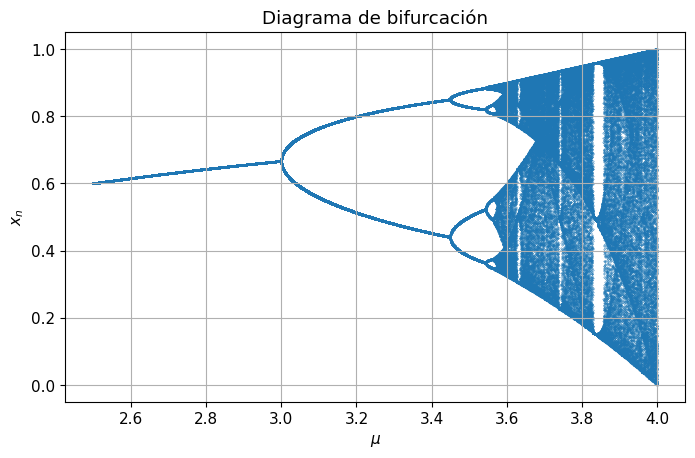

In [ ]:
mu_bif, x_bif = bifurcation_diagram()
plt.figure()
plt.scatter(mu_bif, x_bif, s=0.08)
plt.title("Diagrama de bifurcación")
plt.xlabel(r"$\mu$")
plt.ylabel("$x_n$")
plt.show()

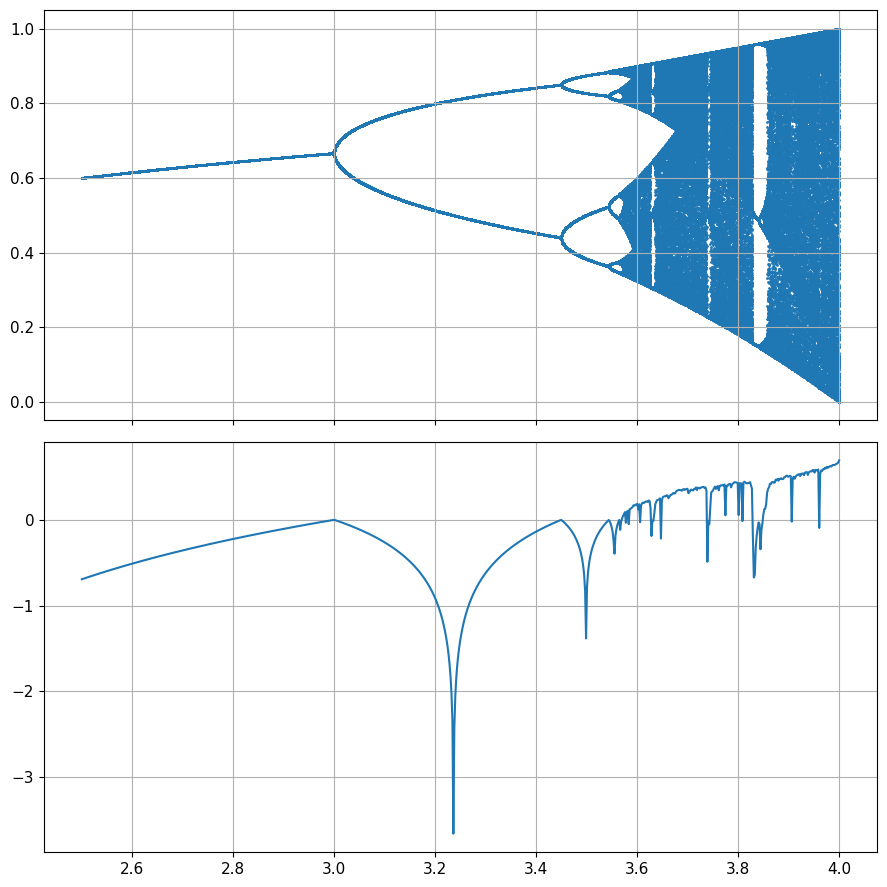

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

ax[0].scatter(mu_bif, x_bif, s=0.98)
ax[1].plot(mu_grid, lambda_values)

plt.tight_layout()
plt.show()
#